In [1]:
import scqubits
import numpy as np
from scipy.optimize import minimize


import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils_models import *
sys.path = original_sys_path

In [2]:
EJ = 2.65
EC = 0.6
EL = 0.13

qubit_level = 30


def get_shift_accurate(ele,omega_i, omega_j, omega_r):
    return abs(ele)**2 / (omega_j-omega_i-omega_r) - abs(ele)**2 / (omega_i-omega_j-omega_r)


qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
evals = qbt.eigenvals(qubit_level)
elements = qbt.matrixelement_table('n_operator',evals_count = qubit_level)

def shift_diff(x):
    Er = x[0]

    shifts_from_one = [get_shift_accurate(elements[1,ql2],evals[ql2],evals[1],Er) for ql2 in range(qubit_level)] 
    shift_from_one = sum(shifts_from_one)
    shifts_from_two = [get_shift_accurate(elements[2,ql2],evals[ql2],evals[2],Er) for ql2 in range(qubit_level)] 
    shift_from_two = sum(shifts_from_two)
    return abs(shift_from_one-shift_from_two)

initial_guess = [7.17391479]

# Call the optimizer
result = minimize(shift_diff, initial_guess, method='Nelder-Mead')

print("Result:", result)
print("Optimal solution:", result.x)
print("Objective value:", result.fun)


Result:        message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 2.178418441731167e-06
             x: [ 7.174e+00]
           nit: 13
          nfev: 27
 final_simplex: (array([[ 7.174e+00],
                       [ 7.174e+00]]), array([ 2.178e-06,  6.199e-06]))
Optimal solution: [7.17391479]
Objective value: 2.178418441731167e-06



qubit 12 transition and differential stark at different oscillator level
qbt freq at osc 0:	0.02161788430113387
qbt freq at osc 1:	0.02162, 	diff to at osc ground 0.00000, 0.0035% diff
qbt freq at osc 2:	0.02162, 	diff to at osc ground 0.00000, 0.0087% diff
qbt freq at osc 3:	0.02162, 	diff to at osc ground 0.00000, 0.0156% diff
qbt freq at osc 4:	0.02162, 	diff to at osc ground 0.00001, 0.0243% diff
qbt freq at osc 5:	0.02163, 	diff to at osc ground 0.00001, 0.0346% diff
qbt freq at osc 6:	0.02163, 	diff to at osc ground 0.00001, 0.0466% diff
qbt freq at osc 7:	0.02163, 	diff to at osc ground 0.00001, 0.0603% diff
qbt freq at osc 8:	0.02163, 	diff to at osc ground 0.00002, 0.0757% diff
qbt freq at osc 9:	0.02164, 	diff to at osc ground 0.00002, 0.0927% diff
qbt freq at osc 10:	0.02164, 	diff to at osc ground 0.00002, 0.1112% diff
qbt freq at osc 11:	0.02165, 	diff to at osc ground 0.00003, 0.1315% diff
qbt freq at osc 12:	0.02165, 	diff to at osc ground 0.00003, 0.1532% diff
qbt freq

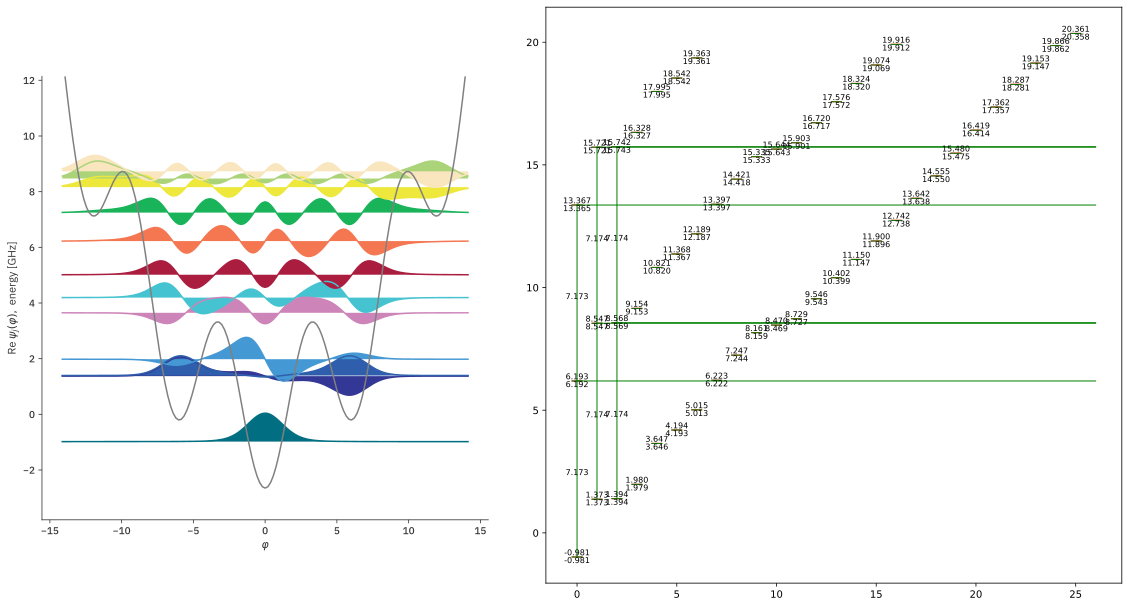

In [3]:
max_ol = 60
max_ql = 30
# g = abs(evals[7]-evals[0]-result.x[0])
# print(f"g:{g}")
g = 0.14
system = FluxoniumOscillatorSystem(
    EJ = EJ,
    EC = EC,
    EL = EL,
    Er = result.x[0],
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    # kappa = 0.004,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '1,2'
    )


energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
def print_stats():
    print(f"\nqubit 12 transition and differential stark at different oscillator level")
    print(f"qbt freq at osc {0}:\t{(dressed_ener(2,0)-dressed_ener(1,0))}")
    ground_freq = dressed_ener(2,0)-dressed_ener(1,0)
    for i in range(1,max_ol-1):
        freq = dressed_ener(2,i)-dressed_ener(1,i)
        print(f"qbt freq at osc {i}:\t{freq:.5f}, \tdiff to at osc ground {freq - ground_freq:.5f}, {abs(freq - ground_freq)/ground_freq*100:.4f}% diff")

    print(f"\noscillator freq at qubit level:\t0 \t 1 \t 2 \t 3:")
    print(f"oscillator transition 0-1: \t{dressed_ener(0,1)-dressed_ener(0,0):.5f}\t{dressed_ener(1,1)-dressed_ener(1,0):.5f}\t{dressed_ener(2,1)-dressed_ener(2,0):.5f}\t{dressed_ener(3,1)-dressed_ener(3,0):.5f}")
    for i in range(1,max_ol-1):
        print(f"oscillator transition {i}-{i+1}: \t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}\t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f}\t{dressed_ener(2,i+1)-dressed_ener(2,i):.5f}\t{dressed_ener(3,i+1)-dressed_ener(3,i):.5f}  oscillator frequency coupled to qubit 0th state compared to 00-01 (non-linearity): {(dressed_ener(0,i+1)-dressed_ener(0,i))  -(dressed_ener(0,1)-dressed_ener(0,0))}")

    print(f"")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(1,1)-dressed_ener(1,0)))}")
    print(f"20-21: {(dressed_ener(2,1)-dressed_ener(2,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
print_stats()
plot_specturum(system.qbt, system.osc, system.hilbertspace,num_levels = 50)

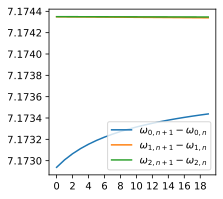

In [16]:
plt.figure(figsize = (3,3))
n_osc_lvls = 20
dressed_osc_frequencies = [[] for _ in range(3)]
for j in [0,1,2]:
    for i in range(0,max_ol-1):
        dressed_osc_frequencies[j].append(dressed_ener(j,i+1)-dressed_ener(j,i))
        
for j in [0,1,2]:
    plt.plot(list(range(max_ol-1))[:n_osc_lvls], dressed_osc_frequencies[j][:n_osc_lvls],label=rf'$\omega_{{{j},n+1}} - \omega_{{{j},n}}$')

plt.xticks(list(range(n_osc_lvls))[::2])
# plt.xticklabels([str(i) for i in range(n_osc_lvls)])
plt.legend(loc='lower right')

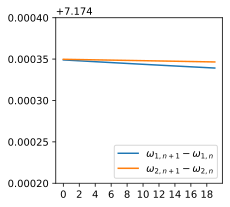

In [20]:
plt.figure(figsize = (3,3))
n_osc_lvls = 20
dressed_osc_frequencies = [[] for _ in range(3)]
for j in [1,2]:
    for i in range(0,max_ol-1):
        dressed_osc_frequencies[j].append(dressed_ener(j,i+1)-dressed_ener(j,i))
        
for j in [1,2]:
    plt.plot(list(range(max_ol-1))[:n_osc_lvls], dressed_osc_frequencies[j][:n_osc_lvls],label=rf'$\omega_{{{j},n+1}} - \omega_{{{j},n}}$')

plt.xticks(list(range(n_osc_lvls))[::2])
# plt.xticklabels([str(i) for i in range(n_osc_lvls)])
plt.ylim(7.1742,7.1744)
plt.legend(loc='lower right')

# Old interaction term

In [76]:
EJ = 2.65
EC = 0.6
EL = 0.13

qubit_level = 30


def get_shift_accurate(ele,omega_i, omega_j, omega_r):
    return abs(ele)**2 / (omega_j-omega_i-omega_r) - abs(ele)**2 / (omega_i-omega_j-omega_r)


qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
evals = qbt.eigenvals(qubit_level)
elements = qbt.matrixelement_table('n_operator',evals_count = qubit_level)

def shift_diff(x):
    Er = x[0]

    shifts_from_one = [get_shift_accurate(elements[1,ql2],evals[ql2],evals[1],Er) for ql2 in range(qubit_level)] 
    shift_from_one = sum(shifts_from_one)
    shifts_from_two = [get_shift_accurate(elements[2,ql2],evals[ql2],evals[2],Er) for ql2 in range(qubit_level)] 
    shift_from_two = sum(shifts_from_two)
    return abs(shift_from_one-shift_from_two)

initial_guess = [7.17391479]

# Call the optimizer
result = minimize(shift_diff, initial_guess, method='Nelder-Mead')

print("Result:", result)
print("Optimal solution:", result.x)
print("Objective value:", result.fun)


Result:        message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 2.178418441731167e-06
             x: [ 7.174e+00]
           nit: 13
          nfev: 27
 final_simplex: (array([[ 7.174e+00],
                       [ 7.174e+00]]), array([ 2.178e-06,  6.199e-06]))
Optimal solution: [7.17391479]
Objective value: 2.178418441731167e-06



qubit 12 transition and differential stark at different oscillator level
qbt freq at osc 0:	0.02161788430113387
qbt freq at osc 1:	0.02162, 	diff to at osc ground 0.00000, 0.0035% diff
qbt freq at osc 2:	0.02162, 	diff to at osc ground 0.00000, 0.0087% diff
qbt freq at osc 3:	0.02162, 	diff to at osc ground 0.00000, 0.0156% diff
qbt freq at osc 4:	0.02162, 	diff to at osc ground 0.00001, 0.0243% diff
qbt freq at osc 5:	0.02163, 	diff to at osc ground 0.00001, 0.0346% diff
qbt freq at osc 6:	0.02163, 	diff to at osc ground 0.00001, 0.0466% diff
qbt freq at osc 7:	0.02163, 	diff to at osc ground 0.00001, 0.0603% diff
qbt freq at osc 8:	0.02163, 	diff to at osc ground 0.00002, 0.0757% diff
qbt freq at osc 9:	0.02164, 	diff to at osc ground 0.00002, 0.0927% diff
qbt freq at osc 10:	0.02164, 	diff to at osc ground 0.00002, 0.1112% diff
qbt freq at osc 11:	0.02165, 	diff to at osc ground 0.00003, 0.1315% diff
qbt freq at osc 12:	0.02165, 	diff to at osc ground 0.00003, 0.1532% diff
qbt freq

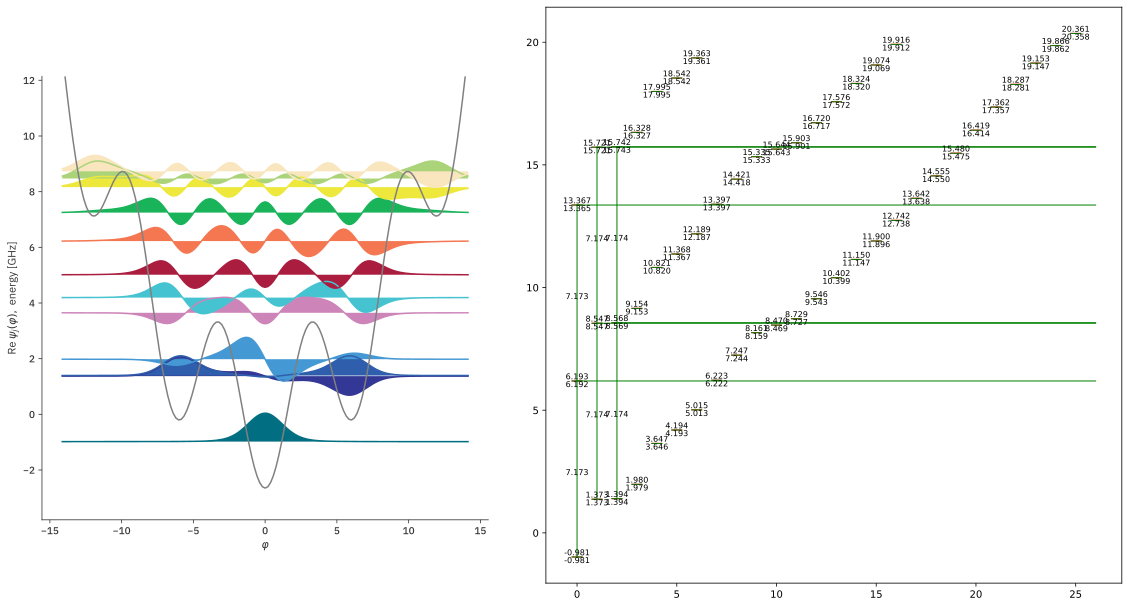

In [77]:
max_ol = 60
max_ql = 30
# g = abs(evals[7]-evals[0]-result.x[0])
# print(f"g:{g}")
g = 0.14
system = FluxoniumOscillatorSystem(
    EJ = EJ,
    EC = EC,
    EL = EL,
    Er = result.x[0],
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    # kappa = 0.004,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '1,2'
    )


energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
def print_stats():
    print(f"\nqubit 12 transition and differential stark at different oscillator level")
    print(f"qbt freq at osc {0}:\t{(dressed_ener(2,0)-dressed_ener(1,0))}")
    ground_freq = dressed_ener(2,0)-dressed_ener(1,0)
    for i in range(1,max_ol-1):
        freq = dressed_ener(2,i)-dressed_ener(1,i)
        print(f"qbt freq at osc {i}:\t{freq:.5f}, \tdiff to at osc ground {freq - ground_freq:.5f}, {abs(freq - ground_freq)/ground_freq*100:.4f}% diff")

    print(f"\noscillator freq at qubit level:\t0 \t 1 \t 2 \t 3:")
    print(f"oscillator transition 0-1: \t{dressed_ener(0,1)-dressed_ener(0,0):.5f}\t{dressed_ener(1,1)-dressed_ener(1,0):.5f}\t{dressed_ener(2,1)-dressed_ener(2,0):.5f}\t{dressed_ener(3,1)-dressed_ener(3,0):.5f}")
    for i in range(1,max_ol-1):
        print(f"oscillator transition {i}-{i+1}: \t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}\t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f}\t{dressed_ener(2,i+1)-dressed_ener(2,i):.5f}\t{dressed_ener(3,i+1)-dressed_ener(3,i):.5f}  oscillator frequency coupled to qubit 0th state compared to 00-01 (non-linearity): {(dressed_ener(0,i+1)-dressed_ener(0,i))  -(dressed_ener(0,1)-dressed_ener(0,0))}")

    print(f"")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(1,1)-dressed_ener(1,0)))}")
    print(f"20-21: {(dressed_ener(2,1)-dressed_ener(2,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
print_stats()
plot_specturum(system.qbt, system.osc, system.hilbertspace,num_levels = 50)

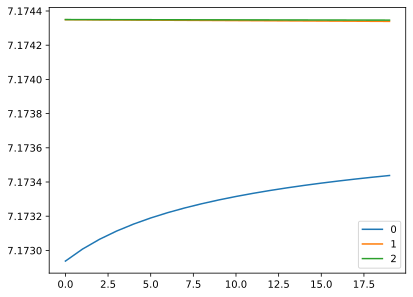

In [78]:
dressed_osc_frequencies = [[] for _ in range(3)]
for j in [0,1,2]:
    for i in range(0,max_ol-1):
        dressed_osc_frequencies[j].append(dressed_ener(j,i+1)-dressed_ener(j,i))
        
for j in [0,1,2]:
    plt.plot(list(range(max_ol-1))[:20], dressed_osc_frequencies[j][:20],label=f'{j}')
plt.legend()